In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Import des données

In [3]:
X = pd.read_csv("C:/Users/AnthonySAINDOY-EODev/Downloads/X_train_update.csv")
y = pd.read_csv("C:/Users/AnthonySAINDOY-EODev/Downloads/Y_train_CVw08PX.csv")

df = X.merge(y, left_index=True, right_on="Unnamed: 0")

# Création des features

In [4]:
df["description"] = df["description"].fillna("")
df["designation"] = df["designation"].fillna("")

df["text"] = df["designation"] + " " + df["description"]
df["text_length"] = df["text"].str.len()
df["has_description"] = df["description"].str.strip().apply(lambda x: 0 if x == "" else 1)

# Distribution des classes

### Voir la répartition des classes 

#### On observe que la classe 2583 est largement dominante avec plus de 10000 représentants. 

In [5]:
import plotly.express as px

top_classes = (
    df["prdtypecode"].astype("str")
    .value_counts()
    .reset_index()
)

top_classes.columns = ["prdtypecode", "count"]

fig = px.bar(
    top_classes,
    x="prdtypecode",
    y="count",
    title="Classes",
    text="count"
)

fig.update_layout(
    xaxis_title="Classe (prdtypecode)",
    yaxis_title="Nombre de produits",
    xaxis_tickangle=-45
)

fig.show()


# Longueur de texte

#### Plus de 35k texte ont entre 0 et 199 mots en description

In [6]:
fig = px.histogram(
    df,
    x="text_length",
    nbins=100,
    title="Distribution de la longueur des textes",
)

fig.update_layout(
    xaxis_title="Longueur du texte (nombre de caractères)",
    yaxis_title="Nombre de produits"
)

fig.show()


# Ratio produits sans description

#### 35% des produits n'ont pas de description, ces produits devronts êtres retirés du df avant modélisation

In [7]:
ratio = df["has_description"].value_counts(normalize=True).reset_index()
ratio.columns = ["has_description", "percentage"]

ratio["has_description"] = ratio["has_description"].map({
    0: "Sans description",
    1: "Avec description"
})

fig = px.pie(
    ratio,
    names="has_description",
    values="percentage",
    title="Ratio produits avec / sans description"
)

fig.show()


In [8]:
print("Nombre total de classes :", df["prdtypecode"].nunique())
print("Longueur mediane texte :", df["text_length"].median())
print("Pourcentage sans description :", (1 - df["has_description"].mean()) * 100)

Nombre total de classes : 27
Longueur mediane texte : 314.0
Pourcentage sans description : 35.09350416882566


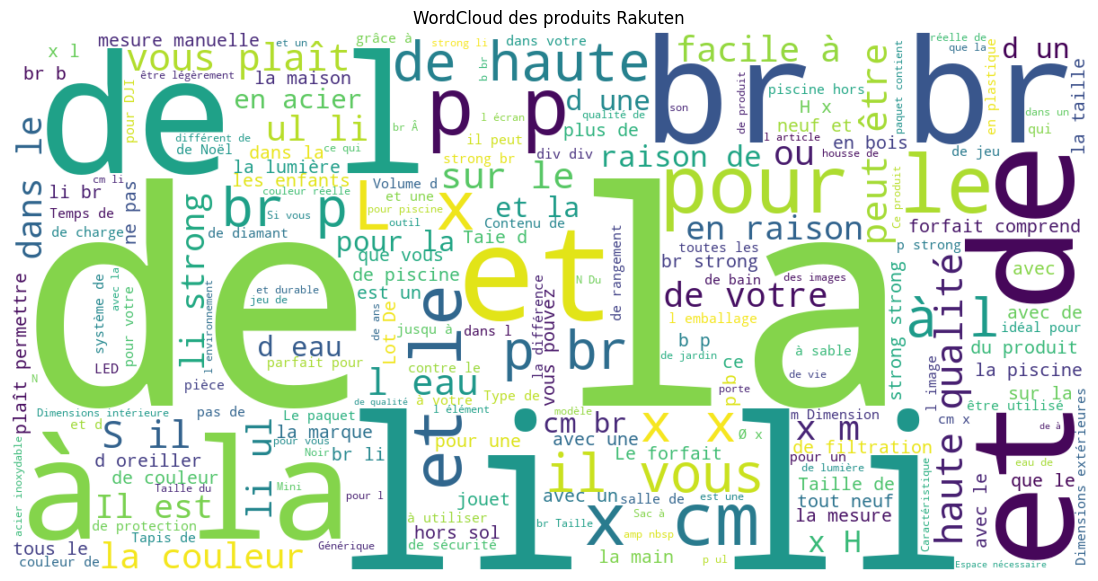

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sample_text = " ".join(df["text"].sample(10000, random_state=42))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(sample_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud des produits Rakuten")
plt.show()
